# 집값 예측 프로젝트 (캐글 2019 ML month with KaKR)

캐글 코리아에서 열렸던 대회다. King County 라는 지역의 집 데이터를 보고 집값(price)을 맞히는 문제.
점수는 RMSE 로 매긴다.

베이스라인 코드에서 시작해서, 한 단계씩 바꿔보면서 점수가 어떻게 달라지는지 직접 실험해봤다.
단계마다 내가 왜 그렇게 했는지랑, 실험으로 나온 결과를 같이 적어놨다.

대회 주소: https://www.kaggle.com/competitions/2019-2nd-ml-month-with-kakr

## 1. 문제랑 점수 매기는 법

test 에 있는 집 6468채의 가격을 예측해서 id, price 형태로 제출하면 된다.

점수는 RMSE 라는 걸 쓴다. 예측값이랑 실제 집값의 차이를 제곱해서, 평균내고, 루트를 씌운 값이다.
차이를 제곱하니까 크게 틀린 게 더 많이 깎인다. 점수는 작을수록 좋은 거다.

이 "제곱이라서 큰 오차에 민감하다" 는 점이 뒤에 3번에서 중요하게 쓰인다.

필요한 라이브러리부터 불러온다.

In [40]:
# 경고 메시지 끄기 (출력 깔끔하게 보려고)
import warnings
warnings.filterwarnings('ignore')

# 기본 도구들
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew   # 분포가 얼마나 한쪽으로 쏠렸는지(왜도) 재는 함수
# 그래프 한글 깨짐 방지
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 음수 기호(-) 깨짐 방지

# 사이킷런 도구들
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# 내가 메인으로 쓸 모델 (LightGBM)
from lightgbm import LGBMRegressor, early_stopping, record_evaluation

## 2. 데이터 먼저 보기

train 이랑 test 를 불러온다.
date 가 '20141013T000000' 이런 식으로 되어 있는데, 앞 6자리(년월)만 있으면 될 것 같아서
잘라서 숫자로 바꿨다. id 는 그냥 일련번호라 학습에는 안 쓴다.

In [2]:
# 데이터 불러오기
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

# date 에서 앞 6자리(년월)만 잘라서 숫자로 바꾸기. train 이랑 test 둘 다 똑같이 처리
for df in (train, test):
    df['date'] = df['date'].apply(lambda x: x[:6]).astype(int)

print('train 크기:', train.shape)
print('test 크기:', test.shape)
train.head()

train 크기: (15035, 21)
test 크기: (6468, 20)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,201410,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,201502,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2,2,201502,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
3,3,201406,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
4,4,201501,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711


In [3]:
# 맞혀야 하는 정답(price)이랑, 단서로 쓸 피처들을 분리한다
price = train['price'].values            # 원래 집값. 점수는 이 단위로 매긴다
X = train.drop(columns=['price', 'id'])  # 피처 = 정답 맞히려고 모델이 보는 단서 칼럼들

print('피처로 쓸 칼럼들:')
print(list(X.columns))

피처로 쓸 칼럼들:
['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


## 3. (내 결정 1) 집값에 로그를 씌워서 학습하기

집값 분포를 보니까 싼 집에 잔뜩 몰려있고, 비싼 집 몇 개가 오른쪽으로 길게 빠져 나가 있다.
이런 모양을 "한쪽으로 쏠려있다(왜도가 크다)" 고 한다.  
  
이걸 그대로 학습시키면 좀 문제가 있을 것 같았다.  
비싼 집은 가격 숫자 자체가 크니까, RMSE(제곱) 입장에선 비싼 집 틀린 걸 줄이는 데만 신경을 쓰게 된다.  
근데 나는 흔한 평범한 집들도 잘 맞히고 싶다.  
  
그래서 집값에 로그를 씌워봤다 (log1p 라는 걸 쓰는데, log(1+x) 라서 0이 들어와도 괜찮다).  
로그를 씌우면 길게 빠진 꼬리가 눌려서 분포가 고르게 펴진다.  
그리고 로그로 보면 차이가 "비율" 처럼 바뀐다고 한다. 그러면 집값이 크든 작든 공평하게 보게 된다.  
  
진짜 효과가 있는지, 같은 모델로 원본이랑 로그를 비교해봤다.

집값 그대로의 왜도: 4.29   (0이면 좌우대칭, 클수록 오른쪽으로 쏠림)
로그 씌운 뒤 왜도: 0.43


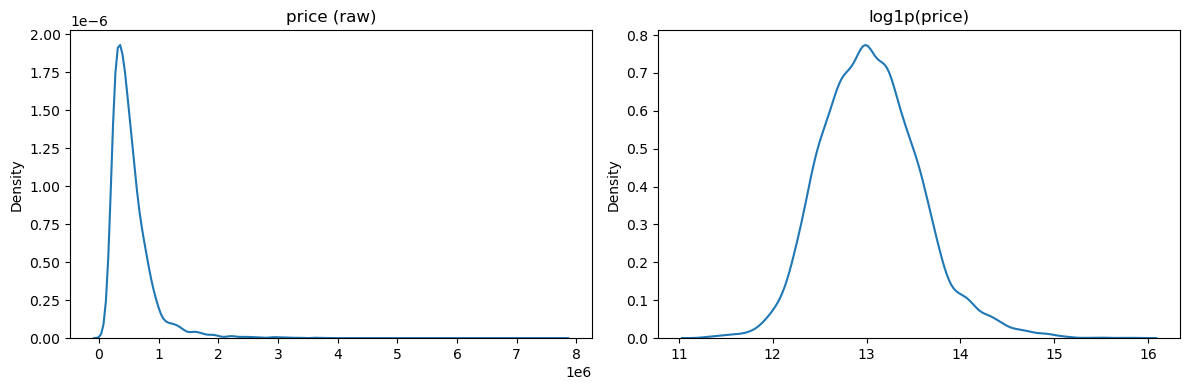

In [4]:
# 로그 씌우기 전후로 분포가 얼마나 달라지는지 숫자(왜도)랑 그래프로 확인
print('집값 그대로의 왜도:', round(skew(price), 2), '  (0이면 좌우대칭, 클수록 오른쪽으로 쏠림)')
print('로그 씌운 뒤 왜도:', round(skew(np.log1p(price)), 2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(price, ax=ax[0]); ax[0].set_title('price (raw)')
sns.kdeplot(np.log1p(price), ax=ax[1]); ax[1].set_title('log1p(price)')
plt.tight_layout(); plt.show()

In [5]:
# 실험: 타깃만 원본 vs 로그로 바꿔서 점수 비교
# (모델이랑 설정은 베이스라인이랑 똑같게: 깊이 10, 나무 100그루)

# 데이터를 5조각으로 나눠서 번갈아 검증하는 방식(5-fold 교차검증)을 쓴다
kf = KFold(n_splits=5, shuffle=True, random_state=2020)

def quick_cv(target, inverse):
    scores = []
    for tr, va in kf.split(X):                 # 5번 반복 (조각마다 한 번씩 검증)
        m = LGBMRegressor(max_depth=10, n_estimators=100, random_state=2020, verbose=-1)
        m.fit(X.iloc[tr], target[tr])          # 학습용 조각으로 학습
        pred = inverse(m.predict(X.iloc[va]))  # 예측한 다음 다시 원래 집값 단위로 되돌림
        scores.append(np.sqrt(mean_squared_error(price[va], pred)))  # RMSE 계산
    return np.mean(scores)

raw_score = quick_cv(price, lambda p: p)            # 원본 집값으로 학습
log_score = quick_cv(np.log1p(price), np.expm1)     # 로그 씌워 학습하고 expm1으로 되돌림

print('원본 집값으로 학습한 점수:', round(raw_score))
print('로그 씌워 학습한 점수:', round(log_score))
print('로그를 씌우니까', round((raw_score - log_score) / raw_score * 100, 1), '% 좋아졌다')

원본 집값으로 학습한 점수: 129435
로그 씌워 학습한 점수: 121762
로그를 씌우니까 5.9 % 좋아졌다


모델은 하나도 안 건드리고 집값에 로그만 씌웠는데 점수가 6% 정도 좋아졌다.
그래서 앞으로는 계속 로그 씌운 값으로 학습하기로 했다.

In [6]:
# 앞으로 계속 쓸 타깃. 로그 씌운 집값이다
y = np.log1p(price)

## 4. 트리 모델은 값의 크기가 아니라 "순서" 만 본다

일단 LightGBM 으로 시작했다. 이유는 세 가지다.  
첫째, 이건 표(table) 데이터라서 트리 부스팅 계열이 보통 잘 맞고 손도 덜 간다고 한다.(이미지나 글이면 딥러닝이겠지만).  
둘째, LightGBM 은 학습이 빨라서 실험을 많이 해보기 좋다고 한다.  
셋째, 베이스라인이 이미 LightGBM 이라 같은 출발선에서 비교하기 편할것 같다.  
(LightGBM 이 유일한 정답일것은 아닌것 같고, 뒤 7번에서 XGBoost, CatBoost 도 같이 써본다.)  
  
LightGBM 은 결정트리를 여러 개 이어붙이는 모델이다.  
트리는 'sqft_living 이 2000보다 큰가?' 이런 식으로 기준값을 잡고 자르기만 한다.  
그러니까 어느 쪽이 더 크냐(순서)만 보지, 실제 숫자 크기는 신경 안 쓴다.  
  
그래서 궁금했다. 피처에 로그를 씌우면(로그는 순서를 안 바꾼다) 트리 점수가 변할까?  
순서가 그대로니까 트리는 별로 안 변할 것 같았다.  
근데 선형 모델은 숫자 크기를 직접 쓰니까 변할 것 같았다. 둘 다 해봤다.

In [7]:
# 한쪽으로 쏠린 피처들 몇 개를 골라서 로그를 씌워볼 거다
skew_cols = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above',
             'sqft_basement', 'sqft_lot15', 'sqft_living15']

def add_feature_log(df):
    d = df.copy()
    for c in skew_cols:
        d[c] = np.log1p(d[c])   # 골라둔 피처들에만 로그 씌우기
    return d

# 트리(LightGBM)로 피처 로그 씌우기 전후 점수
def cv_lgbm_simple(features):
    scores = []
    for tr, va in kf.split(features):
        m = LGBMRegressor(max_depth=10, n_estimators=100, random_state=2020, verbose=-1)
        m.fit(features.iloc[tr], y[tr])
        pred = np.expm1(m.predict(features.iloc[va]))
        scores.append(np.sqrt(mean_squared_error(price[va], pred)))
    return np.mean(scores)

# 선형 모델(Ridge)로도 똑같이 비교. 선형은 표준화를 먼저 해줘야 한다
def cv_ridge(features):
    scores = []
    for tr, va in kf.split(features):
        sc = StandardScaler().fit(features.iloc[tr])    # 평균0 분산1로 맞추기
        m = Ridge(alpha=1.0).fit(sc.transform(features.iloc[tr]), y[tr])
        pred = np.expm1(m.predict(sc.transform(features.iloc[va])))
        scores.append(np.sqrt(mean_squared_error(price[va], pred)))
    return np.mean(scores)

print('트리(LightGBM)')
print('  피처 로그 안씌움:', round(cv_lgbm_simple(X)))
print('  피처 로그 씌움  :', round(cv_lgbm_simple(add_feature_log(X))), '(거의 그대로다)')
print('선형(Ridge)')
print('  피처 로그 안씌움:', round(cv_ridge(X)))
print('  피처 로그 씌움  :', round(cv_ridge(add_feature_log(X))), '(많이 좋아졌다)')

트리(LightGBM)


  피처 로그 안씌움: 121762


  피처 로그 씌움  : 121766 (거의 그대로다)
선형(Ridge)
  피처 로그 안씌움: 213658
  피처 로그 씌움  : 181843 (많이 좋아졌다)


생각한 대로 나왔다. 트리는 피처에 로그를 씌워도 거의 그대로고, 선형 모델은 확 좋아졌다.  
  
그래서 결론은 트리(LightGBM)로 갈 거니까, 지금은 피처 스케일링이나 로그 같은 데는 시간 안 쓰기로 한다.  
트리 모델한텐 별 의미가 없다. 점수는 다른 데서 찾아야 한다.

## 5. (내 결정 2) 학습률 낮추고, 나무 개수는 자동으로 정하기

Gradient Boosting 은 나무를 한 그루씩 더하면서 틀린 만큼을 줄여나가는 방식이다.  
설정할 수 있는 손잡이(?)가 두 개 있다.  
- learning_rate : 나무 한 그루가 얼마나 세게 고치는지. 걸음의 보폭 같은 거다.  
- n_estimators : 나무를 몇 그루나 쓸지. 걸음 수.  

보폭을 작게 하면 나무 한 그루의 영향이 작아져서, 어쩌다 잡음을 외우는 것에 덜 휘둘린다고 한다.  
대신 그만큼 나무가 더 많이 필요하다.  
근데 몇 그루가 적당한지 내가 찍기는 어렵다. 베이스라인은 그냥 100으로 박아놨던데 좀 대충 같았다.  
  
그래서 early stopping(조기종료)을 쓰기로 했다.  
early stopping은 데이터 일부를 검증용으로 따로 빼놓고, 나무를 계속 더하다가 검증 점수가 더 이상 안 좋아지면 멈추는 거다.  
몇 그루 쓸지를 내가 안 정하고 데이터가 정하게 하는 셈이다.  

In [8]:
# 조기종료를 쓰는 교차검증 함수. 점수랑, 조기종료가 고른 나무 수를 같이 돌려준다
def cv_lgbm(features, lr=0.05, max_depth=10, n_estimators=8000):
    scores, n_trees_list = [], []
    for tr, va in kf.split(features):
        m = LGBMRegressor(n_estimators=n_estimators, learning_rate=lr,
                          max_depth=max_depth, random_state=2020, verbose=-1)
        # eval_set 으로 검증용 조각을 알려주면, 거기 점수가 안 좋아질 때 멈춘다
        m.fit(features.iloc[tr], y[tr],
              eval_set=[(features.iloc[va], y[va])], eval_metric='rmse',
              callbacks=[early_stopping(100, verbose=False)])  # 100그루 연속 안 좋아지면 멈춤
        pred = np.expm1(m.predict(features.iloc[va], num_iteration=m.best_iteration_))
        scores.append(np.sqrt(mean_squared_error(price[va], pred)))
        n_trees_list.append(m.best_iteration_)
    return np.mean(scores), np.mean(n_trees_list)

# 학습률을 바꿔가면서, 나무를 몇 그루 고르는지랑 점수를 봤다
for lr in [0.1, 0.05, 0.03, 0.01]:
    score, n_trees = cv_lgbm(X, lr=lr)
    print('학습률', lr, '일때  나무', round(n_trees), '그루,  점수', round(score))

학습률 0.1 일때  나무 416 그루,  점수 118719


학습률 0.05 일때  나무 615 그루,  점수 117290


학습률 0.03 일때  나무 1021 그루,  점수 117500


학습률 0.01 일때  나무 2666 그루,  점수 117977


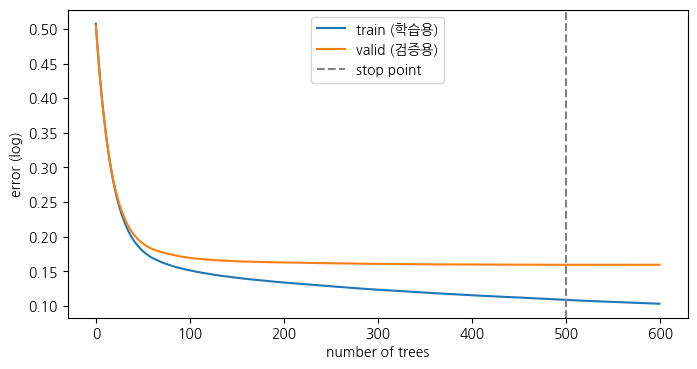

멈춘 나무 수: 500
학습용은 계속 내려가는데(외우는 중), 검증용은 바닥 찍고 평평해진다. 그 지점에서 멈춘 거다.


In [41]:
# 조기종료가 왜 거기서 멈추는지 그래프로 보고 싶었다.
# 학습용 점수랑 검증용 점수를 나무 늘려가며 같이 그려봤다.

Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, random_state=2020)
ev = {}
m = LGBMRegressor(n_estimators=8000, learning_rate=0.05, max_depth=10,
                  random_state=2020, verbose=-1)
m.fit(Xtr, ytr, eval_set=[(Xtr, ytr), (Xva, yva)], eval_names=['train', 'valid'],
      eval_metric='rmse',
      callbacks=[early_stopping(100, verbose=False), record_evaluation(ev)])

plt.figure(figsize=(8, 4))
plt.plot(ev['train']['rmse'], label='train (학습용)')
plt.plot(ev['valid']['rmse'], label='valid (검증용)')
plt.axvline(m.best_iteration_, ls='--', color='gray', label='stop point')
plt.xlabel('number of trees'); plt.ylabel('error (log)'); plt.legend(); plt.show()

print('멈춘 나무 수:', m.best_iteration_)
print('학습용은 계속 내려가는데(외우는 중), 검증용은 바닥 찍고 평평해진다. 그 지점에서 멈춘 거다.')

학습률을 낮출수록 나무를 더 많이 골랐다 (100, 416, 615, 1021, 2666 이런 식으로).  
학습률 0.05 일 때가 점수가 제일 좋았고, 더 낮춰도 별로 안 좋아지고 시간만 더 걸렸다.  
  
그래서 학습률 0.05 에 조기종료(나무 약 615그루)를 기본으로 쓰기로 했다.  
이것만으로 베이스라인 점수가 121762 에서 117290 으로 내려갔다. 피처는 아직 하나도 안 만졌는데도.  

## 6. 피처를 직접 만들어보기 (Feature Engineering)

이번엔 피처 엔지니어링을 해보기로 했다.  
위 5번셀까지 진행한 결과로 1번 파일을 제출했고 결과가 목표치를 돌파하지 못했기 때문이다. (112245 > 110000)
피처 엔지니어링은, 모델이 스스로 못 만드는 정보를 내가 칼럼들을 조합해서 만들어 주는 작업이다.  
트리는 칼럼 하나로 자르는 건 잘 하는데, 칼럼 두 개를 곱하거나 나눈 건 스스로 잘 못 만든다고 한다.  
그래서 그런 조합을 만들어 주면 도움이 될 수도 있다.  
  
일단 모델이 지금 뭘 보고 있는지 중요도부터 봤다.  
여기서 중요도는 그 칼럼으로 질문(split)을 몇 번 했는지 센 거다.  
가격을 잘 갈라주는(나눠보면 비싼 집 싼 집이 깔끔하게 갈리는) 칼럼일수록, 여러 군데서 또 쓰여서 횟수가 높다.  

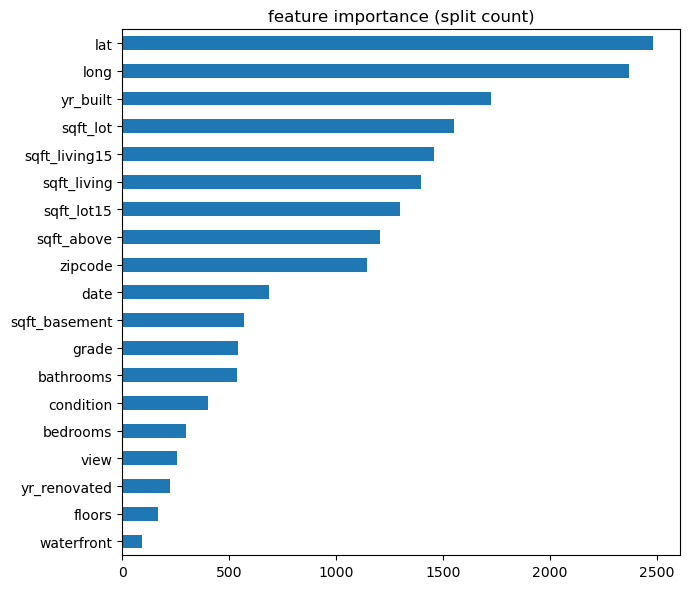

In [10]:
# 모델을 한 번 학습시키고, 어떤 칼럼을 많이 썼는지 본다
m = LGBMRegressor(n_estimators=615, learning_rate=0.05, max_depth=10,
                  random_state=2020, verbose=-1)
m.fit(X, y)

imp = pd.Series(m.feature_importances_, index=X.columns).sort_values()
imp.plot.barh(figsize=(7, 6))
plt.title('feature importance (split count)')
plt.tight_layout(); plt.show()

lat, long (위치)이 제일 많이 쓰였다. 역시 집값은 위치가 제일 중요한 것 같다.  
참고로 waterfront(물가 집, 한강 뷰?)는 횟수가 낮게 나오는데, 한강 뷰 집 자체가 드물어서 쓸 기회가 적은 거지  
중요하지 않다는 뜻은 아닌 것 같다. 이 점은 횟수로만 보는 중요도의 한계인 듯.  
  
이제 내가 생각한 피처들을 하나씩 넣어보고, 점수가 좋아지는 것만 남기기로 했다.

In [11]:
yr = X['date'] // 100   # 거래 년도 (date 가 년월 6자리니까 100으로 나누면 년도)

# 내가 만들어본 후보 피처들
candidates = {
    'age':                2015 - X['yr_built'],                            # 집 나이
    'effective_age':      yr - np.maximum(X['yr_built'], X['yr_renovated']),  # 리모델링 반영한 실제 나이
    'is_renovated':       (X['yr_renovated'] > 0).astype(int),            # 리모델링 했는지 여부
    'living_per_lot':     X['sqft_living'] / X['sqft_lot'],               # 대지 대비 실면적
    'living_vs_neighbor': X['sqft_living'] / X['sqft_living15'],          # 이웃집들 대비 그 집 크기
    'sqft_per_bedroom':   X['sqft_living'] / (X['bedrooms'] + 1),         # 방 하나당 면적
}

base_score, _ = cv_lgbm(X)   # 아무것도 안 넣은 기준 점수
print('기준 점수 (피처 추가 안함):', round(base_score))
print('-' * 40)

for name, col in candidates.items():
    Z = X.copy()
    Z[name] = col.values          # 후보 피처 하나만 추가
    s, _ = cv_lgbm(Z)
    diff = base_score - s         # 양수면 좋아진 거
    if diff > 200:
        verdict = '도움됨'
    elif diff > -200:
        verdict = '별 차이 없음'
    else:
        verdict = '오히려 나빠짐'
    print(name, ':', round(s), ' (차이', round(diff), ')', verdict)

기준 점수 (피처 추가 안함): 117290
----------------------------------------


age : 117290  (차이 0 ) 별 차이 없음


effective_age : 118220  (차이 -930 ) 오히려 나빠짐


is_renovated : 117290  (차이 0 ) 별 차이 없음


living_per_lot : 117654  (차이 -365 ) 오히려 나빠짐


living_vs_neighbor : 117058  (차이 232 ) 도움됨


sqft_per_bedroom : 118748  (차이 -1459 ) 오히려 나빠짐


해보니까 좀 충격이었다. 그럴듯하다고 만든 피처들이 대부분 도움이 안 되거나 오히려 점수를 깎아먹었다.  
공들여 만든 effective_age 도 나빠졌다.  

배운 점이 두 개 있다.  
  
첫째, 피처는 많이 넣는다고 좋은 게 아니다. 그럴듯해 보이는 거랑 진짜 도움 되는 거는 다르다.  
그래서 이렇게 하나씩 넣어보고 점수로 확인하는 게 중요하다. 안 했으면 나쁜 피처를 모르고 넣을 뻔했다.  
  
둘째, 위치(lat, long)를 이미 잘 쓰고 있어서, 내가 손으로 만든 비율 같은 건 별로 새롭지가 않았던 것 같다.  

그래서 손으로 만드는 조합 피처는 일단 접기로 했다. 다음 점수는 다른 데서 찾아봐야겠다.  

## 7. 여러 모델을 하나씩 써보고 섞어보기 (앙상블)

지금까지 LightGBM 하나만 썼는데, 표 데이터에 잘 맞는 모델이 더 있다.  
XGBoost 랑 CatBoost.  
그래서 셋을 다 하나씩 돌려보고 어느 게 제일 좋은지 본 다음에, 섞으면(예측을 평균내면)  
더 좋아지는지 보기로 했다.  
  
섞으면 좋은 이유는, 모델마다 틀리는 지점이 다르기 때문이란다.  
한 모델이 어떤 집에서 헛다리를 짚어도 다른 모델은 다른 데서 틀린다.  
그래서 여러 모델의 예측을 평균내면 서로의 실수가 어느 정도 깎여서 보통 더 안정적이고 점수도 좋아진다고 한다.  

그리고 Out Of Fold라는 개념이 있다.  
'검증 데이터를 어떻게 예측했는지 모아둔다'는 개념이다.  
블렌드 비율을 싸게 비교하려고 모아두는건데. OOF 예측을 한 번 모아두면, 0.5×lgb + 0.5×cat 이든 0.45×cat + ... 이든  
모델 재학습 없이 평균만 바꿔서 점수를 즉석 계산할 수 있다고 한다.  
이번 단계에서는 평균을 낼때 사용하는데, 예측을 평균애기 위해 사용하는 것이다.  
그런데 여기서 중요한 것은 집값 평균을 낼 때 자기 자신의 값은 빼야 한다는 것이다.("자기빼기")  
kf.split(X) 함수가 "자기빼기"를 보장한다.  
train데이터에 자기 자신의 값이 포함되어 있으면 정답이 포함된 평균을 구하게 되므로  
모델이 '과적합'된다.

In [ ]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# 세 모델을 각각 학습시켜서, 검증 데이터를 어떻게 예측했는지 모아둔다(OOF).
# 이렇게 모아두면 나중에 섞는 비율만 바꿔가며 점수를 빠르게 비교할 수 있다.
n = len(X)
oof = {k: np.zeros(n) for k in ['lgb', 'xgb', 'xgb2', 'cat']}  # 모델별 예측을 담아둘 통

for tr, va in kf.split(X):  # 5조각으로 나눠 반복, 여기! kf가 (학습조각, 검증조각) 인덱스를 줌
    Xtr, Xva, ytr, yva = X.iloc[tr], X.iloc[va], y[tr], y[va]

    # LightGBM (앞에서 정한 설정 그대로)
    lgb = LGBMRegressor(n_estimators=8000, learning_rate=0.05, max_depth=10,
                        random_state=2020, verbose=-1)
    lgb.fit(Xtr, ytr, eval_set=[(Xva, yva)], eval_metric='rmse',           # 학습은 tr 로만
            callbacks=[early_stopping(100, verbose=False)])
    oof['lgb'][va] = lgb.predict(Xva, num_iteration=lgb.best_iteration_)   # 예측은 va (자기가 학습 안 한 조각)

    # XGBoost 기본 (깊이 6, 일부러 손 안 댄 버전)
    xgb = XGBRegressor(n_estimators=8000, learning_rate=0.05, max_depth=6,
                       random_state=2020, early_stopping_rounds=100, verbosity=0)
    xgb.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    oof['xgb'][va] = xgb.predict(Xva)

    # XGBoost 손본 버전 (깊이 5로 줄이고 규제 추가, 과적합 줄이려고): 깊은 트리는 잎이 작아져 개별 데이터를 암기(과적합), 얕게/규제하면 잎이 커지고 무작위가 끼어 일반적 패턴만 배운다. (얕게 하면 하나의 잎(최종 예측)에 묶이는 데이터의 양이 많아짐)
    xgb2 = XGBRegressor(n_estimators=8000, learning_rate=0.05, max_depth=5,
                        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                        random_state=2020, early_stopping_rounds=100, verbosity=0)
    xgb2.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    oof['xgb2'][va] = xgb2.predict(Xva)

    # CatBoost
    cat = CatBoostRegressor(iterations=8000, learning_rate=0.05, depth=8,
                            random_state=2020, early_stopping_rounds=100, verbose=False)
    cat.fit(Xtr, ytr, eval_set=(Xva, yva))
    oof['cat'][va] = cat.predict(Xva)

# 모아둔 예측으로 모델 하나하나의 점수를 계산
def rmse_oof(pred_log):
    return np.sqrt(mean_squared_error(price, np.expm1(pred_log)))

print('모델 하나씩 점수:')
print('  LightGBM      :', round(rmse_oof(oof['lgb'])))
print('  XGBoost 기본  :', round(rmse_oof(oof['xgb'])))
print('  XGBoost 손본것:', round(rmse_oof(oof['xgb2'])))
print('  CatBoost      :', round(rmse_oof(oof['cat'])))

모델 하나씩 점수:
  LightGBM      : 117906
  XGBoost 기본  : 123567
  XGBoost 손본것: 117967
  CatBoost      : 116893


CatBoost 가 그냥 돌렸는데 제일 좋게 나왔다. LightGBM 보다도 좋다.  
그리고 XGBoost 는 기본(깊이 6)으로 돌렸더니 셋 중 제일 나빴는데, 깊이를 5로 줄이고 규제를 좀 넣었더니 확 좋아졌다.  
모델을 손도 안 보고 점수만 보고 "얘는 별로네" 하고 판단하면 안 되겠다는 걸 느꼈다.

In [ ]:
# 이제 섞는 비율을 바꿔가며 점수를 비교한다 (모아둔 예측을 평균만 내면 되니 빠르다)
# 무거운 학습은 한 번만(→OOF 저장), 가벼운 "비율 바꿔 평균내기"는 무한 반복. 그래서 블렌드 비율 탐색이 빠르다.
# 사람이 블렌드 비율을 정해야 한다고 하지만 그냥 실무자의 감각이나 최고 결정권자의 결단력으로 정할게 아닌 이상에야
# 이렇게 돌려보면서 비교해보는 과정을 거치는게 필요하다.
blends = {
    'LightGBM + CatBoost 반반':       0.5 * oof['lgb'] + 0.5 * oof['cat'],
    '셋 균등 (기본 xgb)':             (oof['lgb'] + oof['xgb'] + oof['cat']) / 3,
    '셋 균등 (손본 xgb2)':            (oof['lgb'] + oof['xgb2'] + oof['cat']) / 3,
    'CatBoost 많이 (cat .45 lgb .35 xgb2 .2)': 0.45 * oof['cat'] + 0.35 * oof['lgb'] + 0.20 * oof['xgb2'],
}
print('섞은 점수:')
for name, pred in blends.items():
    print('  ', name, ':', round(rmse_oof(pred)))

섞은 점수:
   LightGBM + CatBoost 반반 : 114960
   셋 균등 (기본 xgb) : 116524
   셋 균등 (손본 xgb2) : 115043
   CatBoost 많이 (cat .45 lgb .35 xgb2 .2) : 114884


섞으니까 개별 제일 좋은 CatBoost(약 116900) 보다 다 좋아졌다.  
제일 좋은 건 잘하는 모델에 비중을 더 준 'CatBoost 많이' 조합이었다 (약 114900).  
  
근데 사실 'LightGBM + CatBoost 반반' 이랑 점수 차이가 거의 없었다(몇십 정도).  
이 정도 차이는 그냥 우연일 수도 있지 않을까?  
그래서 비율에 너무 욕심내고 집착하면 오히려 피곤할지도 (사실 벌써 체력이...).  
그래서 세 모델을 다 쓰되 잘하는 쪽에 살짝만 더 비중을 준  
CatBoost 0.45, LightGBM 0.35, XGBoost(손본것) 0.2 로 정하기로 한다.(이게 실무자의 감각? 최고 결정권자의 결단력?)  

아무튼 이걸로 점수가 단일 LightGBM 117290 에서 약 114900 까지 내려왔다.

### 이 블렌드로 제출 파일 만들기 (2번째 제출)

7절에서 정한 비율(CatBoost 0.45 + LightGBM 0.35 + XGBoost 0.2)로, train 전체로 세 모델을 학습시키고
(조기종료 쓰려고 일부를 검증용으로 뺀다) test 예측을 섞어서 제출 파일을 만들었다.

In [20]:
# 조기종료를 쓰려면 검증셋이 필요해서 train 을 다시 8:2 로 나눈다
Xf_tr, Xf_va, yf_tr, yf_va = train_test_split(X, y, test_size=0.2, random_state=2020)
Xtest = test.drop(columns=['id'])

# 세 모델 학습
lgb_f = LGBMRegressor(n_estimators=8000, learning_rate=0.05, max_depth=10,
                      random_state=2020, verbose=-1)
lgb_f.fit(Xf_tr, yf_tr, eval_set=[(Xf_va, yf_va)], eval_metric='rmse',
          callbacks=[early_stopping(100, verbose=False)])

xgb_f = XGBRegressor(n_estimators=8000, learning_rate=0.05, max_depth=5,
                     subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                     random_state=2020, early_stopping_rounds=100, verbosity=0)
xgb_f.fit(Xf_tr, yf_tr, eval_set=[(Xf_va, yf_va)], verbose=False)

cat_f = CatBoostRegressor(iterations=8000, learning_rate=0.05, depth=8,
                          random_state=2020, early_stopping_rounds=100, verbose=False)
cat_f.fit(Xf_tr, yf_tr, eval_set=(Xf_va, yf_va))

# 정한 비율로 섞기 (로그 공간에서 섞고 expm1 으로 원래 집값 단위로 되돌림)
pred_log = 0.45 * cat_f.predict(Xtest) + 0.35 * lgb_f.predict(Xtest) + 0.20 * xgb_f.predict(Xtest)
test_pred = np.expm1(pred_log)

submission = pd.DataFrame({'id': test['id'], 'price': test_pred})
submission.to_csv('./data/submission_02_blend.csv', index=False)
print('제출 파일 저장함: ./data/submission_02_blend.csv')
submission.head()

제출 파일 저장함: ./data/submission_02_blend.csv


,id,price
0,15035,5.173311e+05
1,15036,4.927513e+05
2,15037,1.319359e+06
3,15038,3.043301e+05
4,15039,3.241990e+05


## 8. 위치(zipcode)를 누수 없이 넣어보기

앙상블 모델로 제출해봤더니 점수가 뭐.. 그리 좋지 않다.  
그래서 이번엔 위에서 발견한 중요도를 기준으로 접근해보기로 한다.  
중요도를 보면 lat, long(위치)이 1, 2위였다. 역시 위치가 집값에 제일 중요하다는 거다.  
우리집은 다행히 역세권.  
그런데 zipcode(우편번호)는 트리한테 그냥 숫자라서 잘 못 쓸 것이다 (98178이 98177보다 크다는 게 집값이랑 의미가 없으니까).  
그래서 zipcode 를 '그 동네 평균 집값' 으로 바꿔서 넣어주면 어떨까 했다.  
  
근데 여기 함정이 있는것 같다.  
그냥 train 전체로 동네 평균을 내서 각 집 피처로 붙이면,  
어떤 집의 '동네 평균' 안에 그 집 자신의 가격이 섞여 들어간다.  
그러면 그 피처가 정답을 포함하게 돼서, 학습 땐 점수가 좋아 보이지만 test 에선 무너진다 (정답 누수, leakage 라고 한다).  
test 집은 가격을 모르니까 동네평균에 자기가 안 들어가는데, train 만 자기가 들어가면 불공평한 거다.  
  
그래서 '그 집 자신은 빼고' 나머지 집들로만 평균을 내야 한다 (out-of-fold, "자기 빼기").  
진짜 그런지, 나쁜 방법(누수)이랑 올바른 방법(자기 빼기)을 둘 다 돌려서 비교해봤다.

In [ ]:
# 어떤 피처 구성을 주면 LightGBM 5겹 CV RMSE 를 재주는 함수
def fit_cv_rmse(make_features):
    scores = []
    for tr, va in kf.split(X):
        Xtr, Xva = make_features(tr, va)   # 폴드마다 피처를 만들어 받는다
        m = LGBMRegressor(n_estimators=8000, learning_rate=0.05, max_depth=10,
                          random_state=2020, verbose=-1)
        m.fit(Xtr, y[tr], eval_set=[(Xva, y[va])], eval_metric='rmse',
              callbacks=[early_stopping(100, verbose=False)])
        pred = np.expm1(m.predict(Xva, num_iteration=m.best_iteration_))
        scores.append(np.sqrt(mean_squared_error(price[va], pred)))
    return np.mean(scores)

# (1) 기준: zipcode 인코딩 안 함
def baseline(tr, va):
    return X.iloc[tr], X.iloc[va]

# (2) 나쁜 방법(누수): 전체 데이터로 동네평균을 한 번에 계산, 자기 포함
zip_mean_all = pd.Series(y).groupby(X['zipcode'].values).mean()
X_leak = X.copy()
X_leak['zipcode_te'] = X['zipcode'].map(zip_mean_all).values
def leaky(tr, va):
    return X_leak.iloc[tr], X_leak.iloc[va]

# (3) 올바른 방법(자기 빼기 = out-of-fold)
def oof_encode(zip_tr, ytr, zip_eval, n_inner=5):
    gmean = ytr.mean()
    # 검증 행: 학습폴드 전체로 동네평균 계산 (검증 행은 학습폴드에 없으니 자기가 안 들어감)
    means_full = pd.Series(ytr).groupby(zip_tr).mean()
    enc_eval = pd.Series(zip_eval).map(means_full).fillna(gmean).values
    # 학습 행: 학습폴드 안에서 또 나눠서, 자기 조각은 빼고 계산
    enc_tr = np.full(len(zip_tr), np.nan)
    inner = KFold(n_splits=n_inner, shuffle=True, random_state=0)     # 이 문장으로 학습조각 tr 안에서 또 자기를 뺌. 정답(가격)으로 피처를 만드는 거라, tr 안의 한 집도 자기 가격이 자기 피처에 들어가므로.
    for a, b in inner.split(zip_tr):
        mm = pd.Series(ytr[a]).groupby(zip_tr[a]).mean()
        enc_tr[b] = pd.Series(zip_tr[b]).map(mm).fillna(gmean).values
    return enc_tr, enc_eval

def oof(tr, va):
    Xtr, Xva = X.iloc[tr].copy(), X.iloc[va].copy()
    zt, zv = X['zipcode'].values[tr], X['zipcode'].values[va]
    enc_tr, enc_va = oof_encode(zt, y[tr], zv)
    Xtr['zipcode_te'] = enc_tr
    Xva['zipcode_te'] = enc_va
    return Xtr, Xva

print('기준 (zipcode 인코딩 없음)         :', round(fit_cv_rmse(baseline)))
print('나쁜 방법 (누수: 자기 포함)         :', round(fit_cv_rmse(leaky)), '  <- 좋아 보이지만 가짜')
print('올바른 방법 (자기 빼기 out-of-fold) :', round(fit_cv_rmse(oof)), '  <- 정직한 점수')

기준 (zipcode 인코딩 없음)         : 117290
나쁜 방법 (누수: 자기 포함)         : 116535   <- 좋아 보이지만 가짜
올바른 방법 (자기 빼기 out-of-fold) : 117485   <- 정직한 점수


결과 정리:
- 기준(인코딩 없음): 약 117290
- 나쁜 방법(누수): 약 116535. 기준보다 좋아 보인다. 근데 이건 가짜다. 정답을 훔쳐봐서 부풀려진 점수.
- 올바른 방법(자기 빼기): 약 117485. 기준이랑 거의 같다(살짝 나쁨).

배운 점 두 가지.  
첫째, 누수는 CV 를 거짓말하게 만든다.  
자기 빼기를 안 했으면 'zipcode 효과 있네' 하고 도움도 안 되는 피처를 실을 뻔했다.  
out-of-fold 가 바로 그 거짓말을 막아준 거다.  
  
둘째, 정직하게 보니 zipcode 는 도움이 안 됐다.  
lat, long 이 이미 위치를 잘 잡고 있어서, 동네 평균이 새로 줄 정보가 거의 없었다고 생각된다.(새로운 정보가 없다는 뜻. 정보가 겹친다).  

그래서 zipcode 인코딩은 안 쓰기로 했다. 점수는 못 올렸지만, 누수를 피하는 법을 제대로 익힌 좋은 실험이었다고 생각한다.

### K-means 로 지역을 직접 묶어보기

그래서 이번엔 zipcode 값을 활용하는 것 말고,  
위경도(lat/long)를 K-means 라는 군집 알고리즘으로 직접 K개 구역으로 묶어서  
'지역 번호' 피처를 만들어봤다.  
K-means 는 지도에 집들을 점으로 찍고, 중심점 K개를 잡아  
각 집을 제일 가까운 중심점에 배정하는 방식이다. 위치만 쓰고 가격은 안 보니까 누수 걱정은 없다.  
구역을 몇 개로 나누는 게 좋을지 몰라서 K 를 10, 20, 50, 100 으로 바꿔가며 다 해봤다.

In [15]:
from sklearn.cluster import KMeans

# 기준은 위 zipcode 실험에서 쓴 baseline(클러스터 없음) 함수 그대로 사용
print('기준 (클러스터 없음):', round(fit_cv_rmse(baseline)))

# K 를 바꿔가며 지역 클러스터를 만들어 피처로 넣고 점수를 본다
for k in [10, 20, 50, 100]:
    km = KMeans(n_clusters=k, random_state=2020, n_init=10).fit(X[['lat', 'long']])
    X_km = X.copy()
    X_km['geo_cluster'] = km.labels_          # 각 집에 '지역 번호' 붙이기

    def make(tr, va):                          # 그 피처로 학습/검증 데이터 만들기
        return X_km.iloc[tr], X_km.iloc[va]
    print('K =', k, '구역으로 묶었을 때:', round(fit_cv_rmse(make)))

기준 (클러스터 없음): 117290


K = 10 구역으로 묶었을 때: 117839


K = 20 구역으로 묶었을 때: 118162


K = 50 구역으로 묶었을 때: 118452


K = 100 구역으로 묶었을 때: 117502


결과: K 를 어떻게 잡아도 전부 기준보다 나빴다 (117290 -> 117500 에서 118400 사이).

이유는 zipcode 때랑 똑같다고 생각한다.  
lat, long 이 이미 위치를 정밀하게 갖고 있는데, 클러스터 번호는 그걸 거칠게 뭉뚱그린 거라 새 정보가 없다고 추정된다.  
게다가 '7번 구역' 같은 번호는 임의값이라 (7이 6과 8 사이라는 의미가 없다) 트리한테는 오히려 잡음이 되는것 아닐까.  
  
여기서 세 번 연속 같은 결론이 나왔다: 손으로 만든 비율, zipcode 평균, K-means 구역 전부 효과 없음.  

그래서 내린 결론 - 강한 GBM 에 lat, long 이 이미 있으면 손으로 만든 위치 피처는 대부분 안 먹힌다.  
점수는 피처를 더 쌓는 게 아니라, 모델 튜닝이나 앙상블 구조에서 찾아야 할 것 같다.

## 9. 하이퍼파라미터 튜닝 (num_leaves)

지금까지 max_depth=10 을 줬는데, 사실 num_leaves 는 기본값 31 그대로였다.
그런데 leaf-wise(잎 단위)로 자라는 LightGBM 에서는 num_leaves(잎 최대 개수)가 진짜 복잡도 손잡이다.
여기서 손잡이는 모델이 얼마나 복잡해질지 조절하는 다이얼 같은 것이다.

### 깊이 d 면 잎이 2의 d승 개

트리는 갈림길마다 둘로 쪼개니까, 한 층 내려갈 때마다 끝 박스(잎)가 2배가 된다.

```
깊이 0:        O          잎 1개
깊이 1:      O   O        잎 2개   (1x2)
깊이 2:    O O   O O      잎 4개   (2x2)
깊이 3:  OO OO OO OO      잎 8개   (4x2)
 ...                      ...
깊이 10:                  잎 1024개 (2의 10승)
```

즉 깊이 10 까지 꽉 채우면 잎이 1024개까지 생길 수 있다.

### 그런데 num_leaves=31 이 먼저 막는다

트리 크기를 제한하는 다이얼이 두 개다.
- max_depth : 몇 층까지 내려갈래 (깊이 제한)
- num_leaves : 잎을 최대 몇 개 만들래 (끝 박스 수 제한)

나는 max_depth=10(잎 1024개까지 허용)을 줬지만 num_leaves 는 기본값 31 이었다.
그럼 트리는 잎 31개에서 멈춘다. 잎 31개면 깊이로 쳐도 겨우 5층쯤(2의 5승=32)이라 깊이 10 근처도 못 간다.

```
허용:  max_depth=10  ->  잎 1024개까지 OK
실제:  num_leaves=31 ->  잎 31개에서 멈춤   (이게 먼저 걸린다)
```

즉 max_depth=10 은 헛손잡이였다. 볼륨을 10까지 올려놨는데 옆에서 음소거(31)가 먼저 걸린 셈.
진짜로 트리를 제한한 건 num_leaves=31 이었다. 그래서 튜닝은 max_depth 말고 num_leaves 를 건드렸다.

### LightGBM 은 왜 깊이가 아니라 잎 개수가 손잡이냐

LightGBM 은 잎 단위로 자란다. 균형있게가 아니라 오차가 제일 큰 잎 하나만 골라 깊게 판다.
그래서 트리가 한쪽만 길쭉하게 찌그러진다.

```
[XGBoost  균형(level-wise)]      [LightGBM  한쪽쏠림(leaf-wise)]
        O                                O
       / \                              / \
      O   O                            O   O
     / \ / \                              / \
    O  O O  O                            O   O
                                            / \
                                           O   O    (한쪽만 깊다)
```

이렇게 찌그러진 트리는 깊이로 복잡도를 못 잰다고 한다.  
한 가지는 깊이 15, 다른 가지는 깊이 2 일 수 있으니까.  
반면 잎이 총 몇 개냐(num_leaves)는 모양이 어떻든 복잡도를 정확히 나타낸다.  
그래서 LightGBM 에서는 num_leaves 가 진짜 복잡도 손잡이다.  
  
그래서 num_leaves 를 2 부터 255 까지 바꿔가며 점수를 봤다.

In [ ]:
# num_leaves 를 바꿔가며 CV 점수를 본다 (max_depth 는 풀어둔다) (CV = Cross-Validation(교차검증))
# CV 점수: train 데이터를 여러 조각으로 나눠 "자기가 안 본 조각"을 채점해 평균낸, 처음 보는 데이터 실력의 예행연습 점수. 제출 안 하고도 모델 비교 가능
def cv_nl(num_leaves):
    s = []
    for tr, va in kf.split(X):
        m = LGBMRegressor(num_leaves=num_leaves, max_depth=-1, n_estimators=8000,
                          learning_rate=0.05, random_state=2020, verbose=-1)
        m.fit(X.iloc[tr], y[tr], eval_set=[(X.iloc[va], y[va])], eval_metric='rmse',
              callbacks=[early_stopping(100, verbose=False)])
        s.append(np.sqrt(mean_squared_error(price[va],
                 np.expm1(m.predict(X.iloc[va], num_iteration=m.best_iteration_)))))
    return np.mean(s)

for nl in [2, 5, 15, 31, 63, 127]:
    print('num_leaves =', nl, '-> CV', round(cv_nl(nl)))

num_leaves = 2 -> CV 136381


num_leaves = 5 -> CV 114231


num_leaves = 15 -> CV 117045


num_leaves = 31 -> CV 118002


num_leaves = 63 -> CV 119538


num_leaves = 127 -> CV 122238


In [ ]:
# seed(KFold 의 random_state)를 바꿔가며 CV 를 여러 번 내고 평균낸다.
# 데이터를 어떻게 나누냐(seed)에 따라 CV 가 출렁이므로, 한 seed 에 안 속으려고 3개 평균.
def cv_nl_seed(num_leaves, seed):
    kf_s = KFold(n_splits=5, shuffle=True, random_state=seed)
    s = []
    for tr, va in kf_s.split(X):
        m = LGBMRegressor(num_leaves=num_leaves, max_depth=-1, n_estimators=8000,
                          learning_rate=0.05, random_state=2020, verbose=-1)
        m.fit(X.iloc[tr], y[tr], eval_set=[(X.iloc[va], y[va])], eval_metric='rmse',
              callbacks=[early_stopping(100, verbose=False)])
        s.append(np.sqrt(mean_squared_error(price[va],
                 np.expm1(m.predict(X.iloc[va], num_iteration=m.best_iteration_)))))
    return np.mean(s)

seeds = [2020, 42, 7]
print('num_leaves | seed별 점수 | 평균')
for nl in [5, 6, 8, 15]:
    scores = [cv_nl_seed(nl, sd) for sd in seeds]
    print('  {:>2}  |  {}  |  평균 {}'.format(nl, [round(v) for v in scores], round(np.mean(scores))))

num_leaves | seed별 점수 | 평균
   5  |  [114231, 117500, 115197]  |  평균 115643
   6  |  [114258, 116009, 114786]  |  평균 115018
   8  |  [116635, 118768, 114784]  |  평균 116729
  15  |  [117045, 119182, 116907]  |  평균 117711


작을수록 좋았다. num_leaves=2 는 너무 단순해서 패턴을 못 배워 과소적합(135000 대), 너무 크면 잡음을 외워 과적합.  
바닥은 5~6 근처였다. 이 양쪽 끝이 다 나쁜 U자 모양이 바로 과소적합과 과적합 사이의 균형점을 찾는 그림이다.  
  
한 가지 조심한 것: 단일 seed CV 는 잡음이 커서(±2000 정도) 들쭉날쭉했다. 그래서 seed 를 3개로 바꿔가며 평균을 냈더니  
num_leaves=6 이 흔들림 없이 최저(약 115018)였다. 미세한 결정은 seed 여러 개 평균으로 해야 안 속는것 같다.  
  
min_child_samples, bagging(행/열 샘플링), L2 규제도 얹어봤지만 트리가 이미 작아서 다 효과가 없었다.  
그래서 LightGBM 설정은 num_leaves=6, learning_rate=0.05 로 확정했다. (베이스라인 121762 에서 여기까지 약 115000.)

## 10. 이웃 차이 피처 이식 (11위 솔루션에서 배움)

맨 아래 '참고 솔루션 분석' 에서 본 11위 솔루션의 핵심 아이디어, '이웃 차이 피처' 를 내 모델에 적용해봤다.  
가장 가까운 20채의 여러 속성(sqft_living, grade, 방 개수 등) 평균을 구하고,  
'내 집 값 - 이웃 평균' 차이 피처도 만들었다. 이웃의 가격 평균은 자기를 빼서(out-of-fold) 정답 누수를 막았다.  
속성 평균은 가격이 아니라 누수 걱정이 없다.

In [17]:
from sklearn.neighbors import NearestNeighbors

coords = X[['lat', 'long']].values
attrs = ['sqft_living','sqft_lot','grade','bedrooms','bathrooms','view','condition','sqft_above','sqft_living15']
K = 20

def nb_feats(tr, va, with_diff):
    ctr = coords[tr]; A = X.iloc[tr][attrs].values; ytr = y[tr]
    # 가장 가까운 이웃 찾기. 학습행은 자기(0번째)를 빼고, 검증행은 학습폴드에서
    nn = NearestNeighbors(n_neighbors=K+1).fit(ctr); _, itr = nn.kneighbors(ctr); itr = itr[:, 1:]
    nn2 = NearestNeighbors(n_neighbors=K).fit(ctr); _, iva = nn2.kneighbors(coords[va])
    nb_tr = A[itr].mean(axis=1); nb_va = A[iva].mean(axis=1)   # 이웃 속성 평균
    Xtr = X.iloc[tr].copy(); Xva = X.iloc[va].copy()
    for j, a in enumerate(attrs):
        Xtr['nb_'+a] = nb_tr[:, j];  Xva['nb_'+a] = nb_va[:, j]
        if with_diff:                                          # 차이 피처: 내 집 - 이웃 평균
            Xtr['nbd_'+a] = X.iloc[tr][a].values - nb_tr[:, j]
            Xva['nbd_'+a] = X.iloc[va][a].values - nb_va[:, j]
    Xtr['nb_price'] = ytr[itr].mean(axis=1)                    # 이웃 가격 평균(자기 제외 = 누수 방지)
    Xva['nb_price'] = ytr[iva].mean(axis=1)
    return Xtr, Xva

def cv_nb(mode):
    s = []
    for tr, va in kf.split(X):
        if mode == 'base':  Xtr, Xva = X.iloc[tr], X.iloc[va]
        else:               Xtr, Xva = nb_feats(tr, va, mode == 'diff')
        m = LGBMRegressor(num_leaves=6, max_depth=-1, n_estimators=8000, learning_rate=0.05,
                          random_state=2020, verbose=-1)
        m.fit(Xtr, y[tr], eval_set=[(Xva, y[va])], eval_metric='rmse',
              callbacks=[early_stopping(100, verbose=False)])
        s.append(np.sqrt(mean_squared_error(price[va],
                 np.expm1(m.predict(Xva, num_iteration=m.best_iteration_)))))
    return np.mean(s)

print('기준 (이웃 피처 없음)      :', round(cv_nb('base')))
print('이웃 평균만 (가격+속성)    :', round(cv_nb('mean')))
print('이웃 평균 + 차이 피처      :', round(cv_nb('diff')))

기준 (이웃 피처 없음)      : 114258


이웃 평균만 (가격+속성)    : 112066


이웃 평균 + 차이 피처      : 111072


결과: 기준 약 114000, 이웃 평균을 넣으니 약 112000, 차이 피처까지 넣으니 약 111000 으로 내려갔다.  
(seed 3개 평균으로는 약 112776.) 손으로 만든 비율 피처는 다 실패했는데, 제대로 만든 이웃 차이 피처는 통했다.  
'이 집이 동네 평균보다 얼마나 큰가' 가 트리가 스스로 못 만드는 진짜 새 정보였던 거다.  

이게 내 최고 모델이 됐다. 단일 모델인데 앞에서 만든 3모델 블렌드(114884)보다도 좋다.  
참고로 11위처럼 여러 스케일(5채, 10채, 20채)을 다 합쳐도 봤는데, 피처가 너무 많아져서 오히려 나빠졌다.  
11위는 feature_fraction 과 스태킹으로 많은 피처를 감당했지만 내 단순한 모델은 그게 없어서 그런 듯하다.  

이 모델로 제출 파일을 만들었다 (submission_03_neighbor.csv).

### 이 모델로 제출 파일 만들기 (3번째 제출)

In [ ]:
# === 3번째 제출 파일 만들기: 이웃 차이 피처 단일 LightGBM (num_leaves=6) ===
from sklearn.neighbors import NearestNeighbors

# train(자기 제외) 과 test(train 이웃) 에 이웃 피처를 붙인다
Xtr_nb = X.copy()
Xte_nb = test.drop(columns=['id']).copy()
ctr = Xtr_nb[['lat', 'long']].values
A = Xtr_nb[attrs].values
nn1 = NearestNeighbors(n_neighbors=K+1).fit(ctr); _, itr = nn1.kneighbors(ctr); itr = itr[:, 1:]   # 자기 제외
nn2 = NearestNeighbors(n_neighbors=K).fit(ctr); _, ite = nn2.kneighbors(Xte_nb[['lat', 'long']].values)
nb_tr = A[itr].mean(axis=1); nb_te = A[ite].mean(axis=1)
for j, a in enumerate(attrs):
    Xtr_nb['nb_'+a] = nb_tr[:, j];  Xte_nb['nb_'+a] = nb_te[:, j]
    Xtr_nb['nbd_'+a] = X[a].values - nb_tr[:, j];  Xte_nb['nbd_'+a] = test[a].values - nb_te[:, j]
Xtr_nb['nb_price'] = y[itr].mean(axis=1);  Xte_nb['nb_price'] = y[ite].mean(axis=1)

# 나무 수는 holdout 조기종료로 정하고, 전체로 다시 학습
Xa, Xb, ya, yb = train_test_split(Xtr_nb, y, test_size=0.15, random_state=2020)
m0 = LGBMRegressor(num_leaves=6, max_depth=-1, n_estimators=8000, learning_rate=0.05, random_state=2020, verbose=-1)
m0.fit(Xa, ya, eval_set=[(Xb, yb)], eval_metric='rmse', callbacks=[early_stopping(100, verbose=False)])
final_lgb = LGBMRegressor(num_leaves=6, max_depth=-1, n_estimators=m0.best_iteration_, learning_rate=0.05, random_state=2020, verbose=-1)
final_lgb.fit(Xtr_nb, y)
pred3 = np.expm1(final_lgb.predict(Xte_nb))

sub3 = pd.DataFrame({'id': test['id'], 'price': pred3})
sub3.to_csv('./data/submission_03_neighbor.csv', index=False)
print('저장: submission_03_neighbor.csv (나무', m0.best_iteration_, '그루)')
sub3.head()

저장: submission_03_neighbor.csv (나무 1549 그루)
      id         price
0  15035  5.159773e+05
1  15036  5.076778e+05
2  15037  1.369745e+06
3  15038  2.860158e+05
4  15039  3.261386e+05

## 11. 스태킹 (Stacked Generalization)

참고 폴더에 넣어둔 Wolpert(1992) 논문 'Stacked Generalization' 을 적용했다. 핵심만 정리하면:
- 교차검증은 여러 모델 중 제일 좋은 하나만 고르는데(winner-takes-all), 논문은 이걸 조잡하다고 한다. 스태킹은 모델들을 합친다.
- 핵심: 베이스 모델들을 데이터 일부로 학습시키고, 안 본 부분에 대한 예측(out-of-fold)을 모아서, 그 예측을 입력으로 메타모델을 학습한다.  
       이게 베이스 모델들의 편향을 추론하고 교정하는 것이다. (in-sample 예측을 쓰면 누수가 나는데, 앞에서 배운 out-of-fold 원리 그대로다.)
- winner-takes-all 도 스태킹의 특수한 경우다.

적용: 이웃 피처를 넣은 베이스 모델 4개(LightGBM, XGBoost, CatBoost, Ridge)의 out-of-fold 예측을 모아,  
     단순 평균과 메타모델(Ridge) 스태킹을 비교했다. Ridge 를 넣은 이유는 트리랑 완전히 다르게 틀려서 다양성을 주기 때문이다.

In [18]:
# ===== 스태킹: 여러 모델의 OOF 예측을 모아 결합 =====
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# 베이스 모델 4종. 트리 3개(lgb/xgb/cat) + 선형 1개(ridge).
# 선형은 트리랑 "다르게" 틀려서 다양성을 준다(약해도 섞으면 도움).
base = ['lgb', 'xgb', 'cat', 'ridge']

# oof[모델] = 각 집에 대한 'OOF 예측'(자기를 학습 안 한 모델의 예측)을 담을 통.
# np.zeros(len(X)) = 0으로 채운 빈 배열(집 수만큼)
oof = {m: np.zeros(len(X)) for m in base}

# 데이터를 5조각으로: 매번 4조각(tr)으로 학습 -> 나머지 1조각(va) 예측 -> 그 자리에 저장
for tr, va in kf.split(X):
    Xtr, Xva = nb_feats(tr, va, True)     # 이웃 차이 피처 포함 (10절 함수 재사용, 폴드마다 다시 계산)
    ytr = y[tr]

    # --- LightGBM (메인 모델) ---
    lgb = LGBMRegressor(num_leaves=6, max_depth=-1, n_estimators=8000, learning_rate=0.05,
                        random_state=2020, verbose=-1)
    lgb.fit(Xtr, ytr, eval_set=[(Xva, y[va])], eval_metric='rmse', callbacks=[early_stopping(100, verbose=False)])
    oof['lgb'][va] = lgb.predict(Xva, num_iteration=lgb.best_iteration_)   # 안 본 조각(va) 예측을 저장

    # --- XGBoost (깊이5 + 규제로 과적합 줄인 버전) ---
    xgb = XGBRegressor(n_estimators=8000, learning_rate=0.05, max_depth=5, subsample=0.8,
                       colsample_bytree=0.8, min_child_weight=3, random_state=2020,
                       early_stopping_rounds=100, verbosity=0)
    xgb.fit(Xtr, ytr, eval_set=[(Xva, y[va])], verbose=False); oof['xgb'][va] = xgb.predict(Xva)

    # --- CatBoost ---
    cat = CatBoostRegressor(iterations=8000, learning_rate=0.05, depth=8, random_state=2020,
                            early_stopping_rounds=100, verbose=False)
    cat.fit(Xtr, ytr, eval_set=(Xva, y[va])); oof['cat'][va] = cat.predict(Xva)

    # --- Ridge (선형 모델. 값 크기를 직접 쓰므로 표준화 먼저) ---
    sc = StandardScaler().fit(Xtr); rd = Ridge(alpha=10.0).fit(sc.transform(Xtr), ytr)
    oof['ridge'][va] = rd.predict(sc.transform(Xva))

# OOF 예측을 원래 집값 단위로 되돌려(expm1) 실제 가격과 비교한 RMSE
def rmse_oof(p): return np.sqrt(mean_squared_error(price, np.expm1(p)))

# 1) 모델 하나하나의 점수
print('베이스 모델 OOF 점수:')
for m in base: print('  ', m, ':', round(rmse_oof(oof[m])))

# 2) 단순 평균 블렌드 (4개 예측을 그냥 평균)
print('단순 평균 블렌드 :', round(rmse_oof(np.mean([oof[m] for m in base], axis=0))))

# 3) 스태킹: 베이스들의 OOF 예측 4개를 '입력'으로 삼아, 메타모델(Ridge)이 결합법을 학습.
#    Z = 집마다 [lgb예측, xgb예측, cat예측, ridge예측] 4칸짜리 표
Z = np.column_stack([oof[m] for m in base])
meta_oof = np.zeros(len(X))
for tr, va in kf.split(Z):                                  # 메타모델도 OOF 로 정직하게 평가
    meta = Ridge(alpha=1.0).fit(Z[tr], y[tr]); meta_oof[va] = meta.predict(Z[va])
print('스태킹 (메타 Ridge):', round(rmse_oof(meta_oof)))

베이스 모델 OOF 점수:
   lgb : 111525
   xgb : 116908
   cat : 115648
   ridge : 147479
단순 평균 블렌드 : 107323
스태킹 (메타 Ridge): 110364


결과: 베이스 중 LightGBM 이 제일 좋고(약 111000), Ridge 는 혼자선 형편없었다(약 147000).  
그런데 그 형편없는 Ridge 까지 넣어 단순 평균을 내니 약 107000 으로, 개별 최고보다 4000 이나 좋아졌다.  
Ridge 가 트리랑 완전히 다르게 틀려서, 평균이 서로의 실수를 깎아준 것으로 여겨진다.  
약해도 다르면 도움이 된다는 다양성의 힘일것이다.  

재밌게도 정식 스태킹(메타 Ridge, 약 110000)이 단순 평균(107000)보다 못했다.  
Wolpert 말대로 최선의 결합법은 데이터마다 다르고, 여기서는 단순 평균이 이겼다.

## 12. GPU 실험 (PyTorch 신경망)

트리랑 완전히 다른 모델인 신경망(MLP)을 PyTorch 로 GPU 에서 학습시켜보기로 했다.  
11위 솔루션도 Keras 신경망을 베이스 모델로 넣었었다. 신경망은 값의 크기를 직접 쓴다고 하니까 입력을 표준화해서 넣었다.

In [19]:
# ===== GPU 실험: PyTorch 신경망(MLP)을 베이스 모델로 추가 =====
import torch          # 딥러닝 라이브러리 (텐서 연산 + GPU)
import torch.nn as nn # 신경망 부품(층, 활성화함수 등)

# GPU(ROCm)가 있으면 'cuda', 없으면 'cpu' 로 자동 선택
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch', torch.__version__, '| device:', device,
      '|', torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU')

# MLP = 다층 퍼셉트론(가장 기본 신경망). 입력(d개 피처) -> 128 -> 64 -> 32 -> 1(예측값).
# 숫자가 층의 폭(뉴런 수). SELU = 활성화함수(비선형성을 줘서 복잡한 관계를 배우게 함).
class MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,128), nn.SELU(), nn.Linear(128,64), nn.SELU(),
                                 nn.Linear(64,32), nn.SELU(), nn.Linear(32,1))
    def forward(self, x): return self.net(x).squeeze(-1)   # 입력 x 를 통과시켜 예측을 낸다

# 주의: 신경망은 시작 가중치가 '랜덤'이라, 돌릴 때마다 점수/예측이 조금씩 다르다(트리와의 차이).
def train_mlp(Xtr, ytr, Xva, yva):
    sc = StandardScaler().fit(Xtr)                   # 신경망은 값 크기를 직접 쓰므로 표준화(평균0 분산1)
    # 데이터를 torch 텐서로 바꾸고 GPU(device)로 올린다
    Xt = torch.tensor(sc.transform(Xtr), dtype=torch.float32, device=device)
    Xv = torch.tensor(sc.transform(Xva), dtype=torch.float32, device=device)
    yt = torch.tensor(ytr, dtype=torch.float32, device=device)
    yv = torch.tensor(yva, dtype=torch.float32, device=device)
    m = MLP(Xtr.shape[1]).to(device)                 # 모델을 GPU 에 올림
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)  # 가중치를 조정하는 최적화기(보폭 0.001)
    lf = nn.MSELoss()                                # 손실 = 평균제곱오차
    best, bs, pat = 1e9, None, 0                      # 최고 검증점수 / 그때 가중치 / 인내심 카운터
    for ep in range(1000):                            # 최대 1000번 반복(에폭)
        m.train(); opt.zero_grad()                    # 학습 모드 / 이전 기울기 초기화
        lf(m(Xt), yt).backward()                      # 예측과 정답의 오차로 기울기 계산(역전파)
        opt.step()                                    # 그 방향으로 가중치를 한 걸음 조정
        m.eval()
        with torch.no_grad(): vl = lf(m(Xv), yv).item()   # 검증셋(va) 오차 측정
        # 검증 오차가 줄면 그 가중치를 기억, 안 줄면 인내심 +1 (40번 연속이면 멈춤 = 조기종료)
        if vl < best - 1e-7: best, bs, pat = vl, {k: v.clone() for k, v in m.state_dict().items()}, 0
        else: pat += 1
        if pat >= 40: break
    m.load_state_dict(bs); m.eval()                   # 제일 좋았던 가중치로 되돌림
    with torch.no_grad(): return m(Xv).cpu().numpy()  # va 예측을 CPU 로 빼서 반환

# 트리들처럼 5조각 OOF 로 MLP 예측을 모은다
oof_mlp = np.zeros(len(X))
for tr, va in kf.split(X):
    Xtr, Xva = nb_feats(tr, va, True)
    oof_mlp[va] = train_mlp(Xtr.values, y[tr], Xva.values, y[va])
print('PyTorch MLP (GPU) 5-fold CV RMSE:', round(rmse_oof(oof_mlp)))

# 트리3 + 선형 + 신경망(MLP) 5개를 다 합친 블렌드
oof['mlp'] = oof_mlp
print('5모델 평균 (트리3+선형+신경망):', round(rmse_oof(np.mean([oof[m] for m in ['lgb','xgb','cat','ridge','mlp']], axis=0))))

torch 2.9.1+rocm7.2.1.gitff65f5bc | device: cuda | AMD Radeon Graphics


PyTorch MLP (GPU) 5-fold CV RMSE: 148020
5모델 평균 (트리3+선형+신경망): 109284


결과: MLP 단독 점수는 약 135000 에서 148000 사이로,  
신경망은 시작 가중치가 랜덤이라 실행할 때마다 좀 달라진다(트리보다 한참 약한 건 똑같다).  
테이블 데이터는 트리가 강하고, 신경망은 임베딩이나 튜닝을 더 해야 빛난다.  
하지만 트리랑 완전히 달라서, 베이스에 넣고 블렌드하면 다양성이 늘어 약 107000 으로 내려간다(트리4개 단순평균이 가장 안정적이었다).  
이 5모델 평균으로 최종 제출 파일을 만들었다 (submission_04_stack5.csv).

### 5모델 블렌드로 제출 파일 만들기 (4번째 제출)

In [ ]:
# === 4번째 제출 파일 만들기: 5모델 다양성 블렌드 (위 3번 셀의 Xtr_nb, Xte_nb 재사용) ===
# 주의: 신경망(MLP)은 시작 가중치가 랜덤이라, 이 셀을 다시 돌리면 예측이 조금씩 달라진다(파일도 살짝 바뀜).
import torch, torch.nn as nn
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

device = 'cuda' if torch.cuda.is_available() else 'cpu'
Xa, Xb, ya, yb = train_test_split(Xtr_nb, y, test_size=0.15, random_state=2020)
P = {}  # 모델별 test 예측(로그)

P['lgb'] = final_lgb.predict(Xte_nb)   # 3번 셀에서 학습한 LightGBM 재사용

xgb0 = XGBRegressor(n_estimators=8000, learning_rate=0.05, max_depth=5, subsample=0.8,
                    colsample_bytree=0.8, min_child_weight=3, random_state=2020,
                    early_stopping_rounds=100, verbosity=0)
xgb0.fit(Xa, ya, eval_set=[(Xb, yb)], verbose=False)
xgbf = XGBRegressor(n_estimators=xgb0.best_iteration+1, learning_rate=0.05, max_depth=5, subsample=0.8,
                    colsample_bytree=0.8, min_child_weight=3, random_state=2020, verbosity=0).fit(Xtr_nb, y)
P['xgb'] = xgbf.predict(Xte_nb)

cat0 = CatBoostRegressor(iterations=8000, learning_rate=0.05, depth=8, random_state=2020,
                         early_stopping_rounds=100, verbose=False)
cat0.fit(Xa, ya, eval_set=(Xb, yb))
catf = CatBoostRegressor(iterations=cat0.best_iteration_, learning_rate=0.05, depth=8,
                         random_state=2020, verbose=False).fit(Xtr_nb, y)
P['cat'] = catf.predict(Xte_nb)

sc = StandardScaler().fit(Xtr_nb)
P['ridge'] = Ridge(alpha=10.0).fit(sc.transform(Xtr_nb), y).predict(sc.transform(Xte_nb))

# 주의: 신경망(MLP)은 시작 가중치가 랜덤이라, 이 셀을 다시 돌리면 예측이 조금씩 달라진다(파일도 살짝 바뀜).
class MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,128), nn.SELU(), nn.Linear(128,64), nn.SELU(),
                                 nn.Linear(64,32), nn.SELU(), nn.Linear(32,1))
    def forward(self, x): return self.net(x).squeeze(-1)
scm = StandardScaler().fit(Xtr_nb)
Xta, Xtb, yta, ytb = train_test_split(scm.transform(Xtr_nb), y, test_size=0.15, random_state=2020)
Xta = torch.tensor(Xta, dtype=torch.float32, device=device); Xtb = torch.tensor(Xtb, dtype=torch.float32, device=device)
yta = torch.tensor(yta, dtype=torch.float32, device=device); ytb = torch.tensor(ytb, dtype=torch.float32, device=device)
Xtest_t = torch.tensor(scm.transform(Xte_nb), dtype=torch.float32, device=device)
mlp = MLP(Xtr_nb.shape[1]).to(device); opt = torch.optim.Adam(mlp.parameters(), lr=1e-3); lf = nn.MSELoss()
best, bs, pat = 1e9, None, 0
for ep in range(1000):
    mlp.train(); opt.zero_grad(); lf(mlp(Xta), yta).backward(); opt.step()
    mlp.eval()
    with torch.no_grad(): vl = lf(mlp(Xtb), ytb).item()
    if vl < best - 1e-7: best, bs, pat = vl, {k: v.clone() for k, v in mlp.state_dict().items()}, 0
    else: pat += 1
    if pat >= 40: break
mlp.load_state_dict(bs); mlp.eval()
with torch.no_grad(): P['mlp'] = mlp(Xtest_t).cpu().numpy()

pred4 = np.expm1(np.mean([P[k] for k in ['lgb','xgb','cat','ridge','mlp']], axis=0))
sub4 = pd.DataFrame({'id': test['id'], 'price': pred4})
sub4.to_csv('./data/submission_04_stack5.csv', index=False)
print('저장: submission_04_stack5.csv | device:', device)
sub4.head()

저장: submission_04_stack5.csv | device: cuda
      id         price
0  15035  5.121596e+05
1  15036  5.164938e+05
2  15037  1.382666e+06
3  15038  2.721040e+05
4  15039  3.212751e+05

## 13. 더 해볼 수 있는 것

- 신경망을 더 키우거나 zipcode 임베딩을 붙이면 더 좋아질 수 있다고 한다. (11위 솔루션처럼).
- 이웃 통계를 여러 스케일로 늘리되, feature_fraction 으로 과적합을 막는 방법도 있다고 한다.
- 메타모델을 Ridge 말고 다른 걸로 바꿔보는것도 방법이라고 한다.

## 제출 결과 기록 (리더보드 점수)

실험 단계마다 캐글에 제출한 점수를 여기에 모아둔다.
대회가 끝나서 Late Submission 으로 내는 거라 private 점수가 나온다.

### 제출 요약 (어느 절까지 한 걸로 냈고 점수가 얼마였나)

| 제출 | 반영된 절 | 내용 | Public | Private |
|---|---|---|---|---|
| 1번 | 1~5절 | 단일 LightGBM (로그 타깃 + 학습률 0.05 + 조기종료) | 112,477 | 112,245 |
| 2번 | 1~7절 | 3모델 블렌드 (LightGBM + XGBoost + CatBoost) | 105,578 | 112,644 |
| 3번 | 1~10절 | 이웃 차이 피처 단일 LightGBM (num_leaves=6) | 107,703 | 109,586 |
| 4번 | 1~12절 | 5모델 다양성 블렌드 (트리3 + Ridge + GPU 신경망) | 105,994 | 106,130 |

최종 등수는 private 로 정한다. private 베스트는 4번(106,130)이고, 시작점인 1번(112,245)에서 약 6000 내렸다.

제출 안 한 절: 6절(손FE)과 8절(zipcode, KMeans)은 효과가 없던 실험이라 제출하지 않았다.
9절(num_leaves 튜닝)은 그 결과(num_leaves=6)가 10절 이웃 모델에 흡수되어 3번 제출에 들어갔다.

아래는 각 제출의 리더보드 캡쳐다.

### 사다리 1단계: 단일 LightGBM (CV 약 117,290)

![사다리1 리더보드 점수](images/1.png)

private 점수 112245, public 점수 112477 이 나왔다.
내 CV(117,290)보다 5천쯤 더 좋게 나왔는데, CV 는 데이터를 80%만 보고 학습하는데
제출용 모델은 train 100%를 다 보고 학습해서 그런 것 같다.
어쨌든 CV 가 리더보드를 잘 따라간다는 걸 확인했으니, 다음 실험들은 CV 를 믿고 진행하기로 했다.

### 사다리 2단계: 세 모델 블렌드 (CV 약 114,884)

![블렌드 리더보드 점수](images/2.png)

이번엔 결과가 좀 복잡하게 나왔다.
- public 점수: 112477 에서 105578 로 확 좋아졌다 (7천 가까이)
- private 점수: 112245 에서 112644 로 오히려 살짝 나빠졌다

캐글은 test 를 public 이랑 private 두 덩어리로 나눠서 점수를 따로 매긴다. 최종 등수는 private 로 정한다.
그런데 같은 파일인데 public(105578)이랑 private(112644)이 7천이나 차이난다.
이건 두 덩어리의 성격이 꽤 다르고, 점수에 우연(변동)이 크다는 뜻이다.

배운 점: 내 CV 는 블렌드가 더 좋다고 했고(114884) public 도 확 좋아졌는데, 정작 private 은 거의 그대로였다.
즉 작은 점수 차이(몇백에서 몇천)는 그냥 우연일 수 있으니 너무 믿으면 안 된다.
private 을 확실히 더 내리려면 미세 조정 말고 더 크고 단단한 개선이 필요할 것 같다.
다음엔 위치 정보(zipcode)를 제대로 넣어보기로 했다.

### 사다리 3단계: 이웃 차이 피처 (CV 약 112,776)

![이웃 차이 피처 리더보드 점수](images/3.png)

드디어 110000 을 뚫었다. private 109586, public 107703.
CV(112776)보다 약 3000 더 좋게 나왔는데, 역시 제출 모델은 train 을 100% 다 보고 학습해서 그런 것 같다.

손으로 만든 비율이나 zipcode 평균은 다 실패했는데, 11위 솔루션에서 배운 '이웃 차이 피처'
(이 집이 동네 평균보다 얼마나 큰가)는 제대로 통했다. 상위 솔루션을 공부한 게 실제 점수로 돌아온 셈이다.

### 사다리 4단계: 5모델 다양성 블렌드 (CV 약 107,000)

![5모델 블렌드 리더보드 점수](images/4.png)

private 106130, public 105994. 또 최고를 갱신했고 110000 을 확실히 넘었다.

눈에 띈 점: 예전 블렌드는 public 105000 / private 112000 으로 7000 이나 벌어졌는데(불안정),
이번 다양성 블렌드는 public(105994)이랑 private(106130)이 거의 붙었다.
트리, 선형, 신경망을 다 섞으니 더 안정적으로 일반화한 것이다.

정리하면 ladder1(private 112245) 에서 시작해 여기까지 약 6000 을 내렸다.

## 참고한 자료

이 대회를 먼저 푼 분들의 커널이랑 정리 글을 참고했다.
거기서 쓴 기법들(파생변수, 지오 피처, 스태킹 같은 것)을 보고 내 실험 방향을 잡았다.

- 대회 페이지: https://www.kaggle.com/c/2019-2nd-ml-month-with-kakr
- 베이스라인 커널 (kcs93023): https://www.kaggle.com/kcs93023/2019-ml-month-2nd-baseline
- Geo Data EDA & Feature Engineering (tmheo74): https://www.kaggle.com/code/tmheo74/geo-data-eda-and-feature-engineering
- KaKR House Price FE 정리 (creedmaestro 블로그): https://creedmaestro.github.io/project/2019/04/10/KaKR_House_Price_Prediction_with_R(FE).html
- 솔루션 저장소 (noveline4530, GitHub): https://github.com/noveline4530/2019_2nd_ml_month_with_kakr

## 참고 솔루션 분석: 11위 솔루션 (public 98316, private 99336)

내 점수(private 112245)보다 13000 이나 좋은 상위 솔루션을 구해서 코드를 직접 읽고 공부했다.
작성자는 tmheo74 이고, 같은 사람이 'Geo Data EDA' 랑 'Generate Neighbor Data' 커널도 만들었다.
읽어보니 단 하나의 비법이 아니라, 대량 피처 엔지니어링과 2단계 스태킹을 합친 종합 작품이었다.

### 1. 이상치 제거
딱 한 줄이었다. sqft_living 이 12000 보다 큰데 price 가 300만 보다 싼 집(거대한데 이상하게 싼 = 오류성)을 지웠다.
참고로 내 데이터를 확인해보니 예전에 유명했던 방 33개짜리 입력오류 집은 이미 보정돼 있었다.

### 2. 피처 엔지니어링 (아주 많음)
- 날짜 분해: 판 연도 / 분기 / 주 / 요일, 그리고 yr_sold - yr_built(집 나이) 같은 차이값
- 비율 피처: sqft_living/bedrooms, bathrooms/bedrooms, sqft_living*grade, overall(grade+view+condition 등을 다 더한 종합점수) 등 아주 많이
- zipcode 를 자릿수로 쪼갬: 3째자리, 4째자리, 5째자리, 그리고 그 조합들. 전부 one-hot 으로 펼침
- 지오 피처: lat/long 에 PCA 를 걸어 좌표를 회전시키고, KMeans 로 72개 구역을 만들고, 중심점에서의 방향각(bearing)을 계산해 10등분
- groupby 평균가격: grade, bedrooms, view 같은 그룹별 평균 price 를 붙임

### 3. 핵심 비법: 이웃(neighbor) 통계
이게 점수를 끌어올린 진짜 비법이다. 나는 '가장 가까운 K채의 평균 가격' 하나만 만들었는데, 이 솔루션은 훨씬 풍부했다.

- 여러 스케일: 반경 1km / 3km / 5km 안의 집들, 그리고 가장 가까운 5채 / 10채 / 20채. 총 6가지 범위로 각각 통계를 냄.
- 여러 속성: 이웃의 가격뿐 아니라 sqft_living, sqft_lot, bedrooms, bathrooms, grade, view, condition 의 평균도 다 구함.
- 가장 똑똑한 부분 - 차이(difference) 피처: '내 집 sqft_living - 이웃 평균 sqft_living' 처럼, 이 집이 동네 평균보다 얼마나 크고 좋은지를 피처로 만들었다.

이 '동네 대비 상대값' 이 강력한 이유: 트리는 이런 비교를 스스로 만들기 어렵다.
'이 집은 이웃보다 500 크다' 는 비쌀 만한 신호인데, 그걸 직접 계산해서 떠먹여 준 것이다.
거리는 haversine(지구가 둥근 걸 반영한 거리) 공식으로 쟀다.

### 4. 2단계 스태킹
- 1단계: 스케일별로 만든 8가지 피처셋 각각에, 약 9개 모델(LightGBM 3종 - 잎 7/31/63, XGBoost 3종 - 깊이 3/10/20, RandomForest 2종, Ridge)을 돌려서 out-of-fold 예측을 뽑는다.
- 2단계: 그 예측들을 모아서 또 다른 모델들(Keras 신경망, ExtraTrees, LightGBM)로 다시 학습한다. 모델의 예측을 입력으로 받는 모델인 셈이다.
- 다양성이 핵심: 깊은 모델과 얕은 모델, 트리와 선형과 신경망을 섞었다. 서로 다르게 틀리니까 합치면 좋아진다.
- 눈에 띈 설정: learning_rate 가 0.01 로 아주 낮고, num_leaves=7 짜리 얕은 LightGBM 도 멤버로 넣었다. feature_fraction=0.2 라서, 피처가 많아진 만큼 나무마다 20%만 보게 했다.

### 공부하며 알게 된 점 (내 실험과의 연결)
- 이 솔루션도 얕은 트리(num_leaves=7)를 핵심 멤버로 썼다. 내가 num_leaves 튜닝에서 '작을수록 좋다' 고 찾은 결과랑 일치한다.
- 내가 만든 단순 이웃 평균가격이 1000 정도밖에 효과가 없던 이유를 알았다. 차이 피처, 다중 스케일, 스태킹이 빠져서였다.
- KMeans 클러스터를 내가 트리에 raw 정수로 넣었을 땐 효과가 없었는데, 이 솔루션은 one-hot 으로 만들어 선형/신경망 모델에 먹였다. 같은 도구라도 쓰는 곳이 달랐다.

### 이 프로젝트에 이식해볼 것
전체 복제는 시간이 부족해 무리지만, 가성비 좋은 아이디어를 골라 적용해보기로 했다.
1. 이웃 차이 피처 (내 집 속성 빼기 이웃 평균)
2. 이상치 한 줄 제거
3. 여유되면 스태킹

참고 커널: https://www.kaggle.com/tmheo74/11th-solution-public-98316-private-99336

## 회고

### 전체 흐름과 점수 변화

베이스라인 CV 약 121,762 에서 시작해, 한 단계씩 바꿔보며 진행했다. 전체 흐름은 이렇다.

```
데이터 준비 -> 타깃 로그변환 -> (트리는 순서만 본다 이해)
   -> 학습률 0.05 + 조기종료 -> 손FE 시도(실패) -> 3모델 블렌드
   -> zipcode 인코딩 / KMeans(실패) -> num_leaves 튜닝
   -> 이웃 차이 피처 -> 스태킹 -> GPU 신경망(MLP)
```

제출별 private 점수(낮을수록 좋음):

```
1번  단일 LightGBM       112,245
2번  3모델 블렌드        112,644
3번  이웃 차이 피처      109,586   (110,000 돌파)
4번  5모델 다양성 블렌드 106,130   (최고)
```

시작점에서 약 6,000 을 내렸다.

### 배운 점

- 점수는 피처를 많이 쌓는다고 오르는 게 아니었다. 
  내가 만든 비율 피처, zipcode 평균, KMeans 구역은 다 효과가 없었다.  
  강한 모델에 lat/long 이 이미 있으면 어설픈 위치 피처는 거부당한다는 걸 세 번이나 확인했다.
- 진짜 점수는 세 군데서 나왔다.  
  (1) 트리가 스스로 못 만드는 새 정보 — 이웃 차이 피처("이 집이 동네보다 얼마나 큰가").  
  (2) 모델 튜닝 — num_leaves 를 작게.  
  (3) 다양성 앙상블 — 약한 모델도 다르게 틀리면 도움이 된다.
- 개념도 많이 잡혔다.  
  타깃에 로그를 씌우면 오차가 비율로 바뀐다, 트리는 값 크기가 아니라 순서만 본다,  
  학습률을 낮추고 조기종료로 나무 수를 자동으로 정한다, num_leaves 가 LightGBM 의 진짜 복잡도 손잡이다,  
  정답 누설은 OOF(자기 빼기)로 막는다, CV 는 seed 에 따라 출렁이니 여러 개 평균으로 본다,  
  스태킹은 모델들의 OOF 예측을 메타모델로 결합하는 것이다.
- 상위 솔루션(11위)과 논문(Wolpert 1992)을 직접 읽고 적용한 게 실제 점수로 이어졌다. 거인의 어깨에서 바라모는 시야란 이런거구나.. 하고 생각해봤다.  
- GPU 로 신경망(MLP)도 처음 돌려봤다.

### 아쉬운 점

- 11위 솔루션처럼 다중 스케일 이웃 통계(1/3/5km + 5/10/20채)나 2단계 스태킹, zipcode 임베딩 신경망까지는 못 갔다. 시간과 실력이 부족했다.
- 신경망(MLP)을 제대로 못 살렸다. 혼자선 트리보다 한참 약했는데, 임베딩이나 구조 튜닝을 더 했으면 베이스 모델로 더 기여했을 것 같다.
- 정식 스태킹이 단순 평균보다 점수가 낮게 나왔다. 메타모델을 다른 걸로 바꾸거나 더 많은 베이스를 넣어봤으면 어땠을까 싶다.

### 느낀 점

- 제일 크게 느낀 건 "내 검증(CV)을 믿을 수 있나"가 핵심이라는 점이다.  
  제출이 5번뿐이라 거의 모든 결정을 CV 로 했는데, CV 가 리더보드를 잘 따라가는지 확인하고 나서야 마음 놓고 진행할 수 있었다.
- 실패한 실험(손FE, zipcode, KMeans)도 그냥 버리지 않고 "왜 안 됐는지"까지 기록하니 오히려 더 많이 배웠다.  
  실패가 데이터로 남으니 다음 판단이 쉬워졌다.
- 개념이 막연할 때 그냥 넘어가지 않고 "왜 그런지"를 하나씩 파고든 게 제일 도움이 됐다.  
  OOF, 과적합, num_leaves 같은 게 처음엔 흐릿했는데 끝까지 추적해보니 얻는게 많이 생겼다.